# Chapter 1: Neural Network Foundations Using Python and NumPy

*Deep Learning Crash Course - BPB Publications*

This notebook contains the complete, executable code for Chapter 1, covering perceptrons, activation functions, forward propagation, loss functions, backpropagation, optimisers and a final from-scratch neural network , concluded with solutions to the chapter exercises.

**Sections**
1. Setup and helpers
2. Perceptron implementation
3. Activation functions
4. Forward propagation through multiple layers
5. Loss functions
6. Backpropagation and training the XOR problem
7. Optimisers (SGD, Momentum, RMSprop, Adam)
8. Complete neural network on a real dataset
9. TensorFlow/Keras equivalent
10. Exercise solutions


## 1. Setup and helpers

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMG_DIR = Path('images')
IMG_DIR.mkdir(exist_ok=True)

def save_fig(name, fig=None, dpi=150):
    """Save the current (or given) figure as PNG into the chapter images folder."""
    fig = fig or plt.gcf()
    path = IMG_DIR / f'{name}.png'
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'Saved {path}')

RNG = np.random.default_rng(seed=42)
print('NumPy version:', np.__version__)


## 2. Perceptron implementation

Rosenblatt's perceptron learns a linear decision boundary by adjusting weights whenever it misclassifies a training example.

In [2]:
class Perceptron:
    def __init__(self, n_features, lr=0.1, epochs=20):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs
        self.history = []

    def predict(self, X):
        return np.where(X @ self.w + self.b >= 0.0, 1, 0)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                update = self.lr * (target - self.predict(xi.reshape(1, -1))[0])
                self.w += update * xi
                self.b += update
                errors += int(update != 0.0)
            self.history.append(errors)
            if errors == 0:
                break
        return self

# Linearly separable AND-gate-like data
X_lin = np.array([[2, 3], [1, 1], [2, 1], [3, 2], [6, 5], [7, 7], [8, 6], [7, 8]])
y_lin = np.array([0, 0, 0, 0, 1, 1, 1, 1])

p = Perceptron(n_features=2, lr=0.1, epochs=20).fit(X_lin, y_lin)
print('Training errors per epoch:', p.history)
print('Final accuracy:', (p.predict(X_lin) == y_lin).mean())


Training errors per epoch: [2, 3, 4, 4, 4, 5, 2, 0]
Final accuracy: 1.0


Saved images/01_perceptron_boundary.png


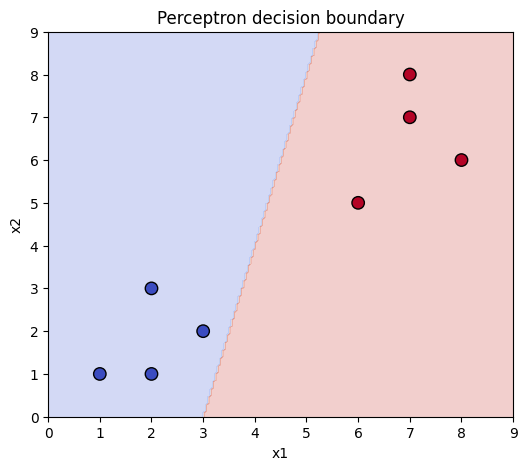

In [3]:
# Decision boundary visualisation
xx, yy = np.meshgrid(np.linspace(0, 9, 200), np.linspace(0, 9, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = p.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, preds, alpha=0.25, cmap='coolwarm')
ax.scatter(*X_lin.T, c=y_lin, cmap='coolwarm', edgecolor='k', s=80)
ax.set_title('Perceptron decision boundary')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
save_fig('01_perceptron_boundary')
plt.show()


In [4]:
# Demonstrating that a single perceptron cannot solve XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])
p_xor = Perceptron(n_features=2, lr=0.1, epochs=200).fit(X_xor, y_xor)
acc = (p_xor.predict(X_xor) == y_xor).mean()
print(f'XOR accuracy with a single perceptron: {acc:.2f} (cannot exceed 0.75)')


XOR accuracy with a single perceptron: 0.50 (cannot exceed 0.75)


## 3. Activation functions

Activation functions give a network its non-linearity. We visualise each function and its derivative side-by-side.

Saved images/02_activations.png


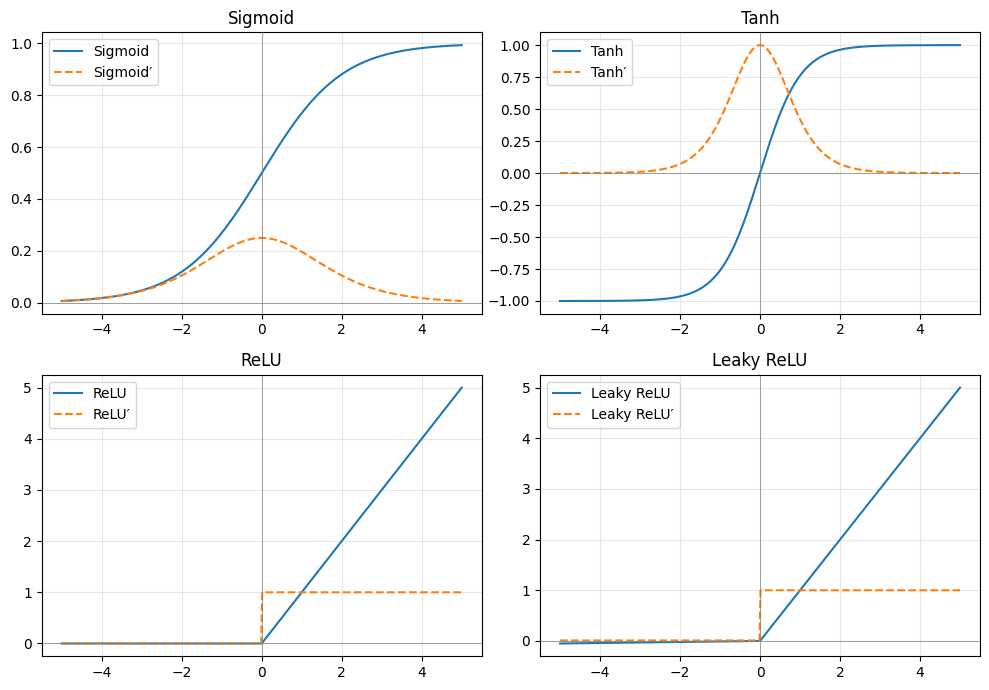

In [5]:
def sigmoid(x):        return 1.0 / (1.0 + np.exp(-x))
def sigmoid_deriv(x):  s = sigmoid(x); return s * (1 - s)
def tanh(x):           return np.tanh(x)
def tanh_deriv(x):     return 1 - np.tanh(x) ** 2
def relu(x):           return np.maximum(0.0, x)
def relu_deriv(x):     return (x > 0).astype(float)
def leaky_relu(x, a=0.01): return np.where(x > 0, x, a * x)
def leaky_relu_deriv(x, a=0.01): return np.where(x > 0, 1.0, a)
def softmax(z):
    e = np.exp(z - z.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

x = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (name, f, fd) in zip(axes.flat, [
    ('Sigmoid', sigmoid, sigmoid_deriv),
    ('Tanh', tanh, tanh_deriv),
    ('ReLU', relu, relu_deriv),
    ('Leaky ReLU', leaky_relu, leaky_relu_deriv),
]):
    ax.plot(x, f(x), label=name)
    ax.plot(x, fd(x), '--', label=f'{name}\u2032')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(name); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); save_fig('02_activations'); plt.show()


## 4. Forward propagation through multiple layers

A multi-layer perceptron stacks affine transforms and non-linearities. We use He initialisation for ReLU layers.

In [6]:
class MLP:
    def __init__(self, layer_sizes, activations, seed=0):
        rng = np.random.default_rng(seed)
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.params = {}
        for l in range(1, len(layer_sizes)):
            fan_in = layer_sizes[l - 1]
            scale = np.sqrt(2.0 / fan_in)  # He init for ReLU
            self.params[f'W{l}'] = rng.standard_normal((layer_sizes[l - 1], layer_sizes[l])) * scale
            self.params[f'b{l}'] = np.zeros((1, layer_sizes[l]))

    def _act(self, name, z):
        return {'relu': relu, 'sigmoid': sigmoid, 'tanh': tanh,
                'softmax': softmax, 'linear': lambda x: x}[name](z)

    def forward(self, X):
        cache = {'A0': X}
        A = X
        for l in range(1, len(self.layer_sizes)):
            Z = A @ self.params[f'W{l}'] + self.params[f'b{l}']
            A = self._act(self.activations[l - 1], Z)
            cache[f'Z{l}'] = Z; cache[f'A{l}'] = A
        return A, cache

net = MLP([4, 8, 3], ['relu', 'softmax'])
X_demo = np.random.randn(5, 4)
out, _ = net.forward(X_demo)
print('Output shape:', out.shape, 'row sums:', out.sum(axis=1))


Output shape: (5, 3) row sums: [1. 1. 1. 1. 1.]


## 5. Loss functions

In [7]:
def mse(y, y_hat):                return np.mean((y - y_hat) ** 2)
def bce(y, y_hat, eps=1e-12):     y_hat = np.clip(y_hat, eps, 1 - eps); return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
def cce(y_onehot, y_hat, eps=1e-12): y_hat = np.clip(y_hat, eps, 1 - eps); return -np.mean(np.sum(y_onehot * np.log(y_hat), axis=1))

y_true = np.array([1.0, 0.0, 1.0, 1.0])
y_pred = np.array([0.9, 0.1, 0.8, 0.4])
print(f'MSE: {mse(y_true, y_pred):.4f}')
print(f'Binary CE: {bce(y_true, y_pred):.4f}')

y_oh = np.eye(3)[[0, 1, 2, 0]]
y_logits = np.random.randn(4, 3)
print(f'Categorical CE: {cce(y_oh, softmax(y_logits)):.4f}')


MSE: 0.1050
Binary CE: 0.3375
Categorical CE: 2.2035


## 6. Backpropagation: training XOR end-to-end

We derive gradients via the chain rule for a 2-2-1 network with sigmoid output.

Predictions: [0 0 1 1] Truth: [0 1 1 0]
Saved images/03_xor_loss.png


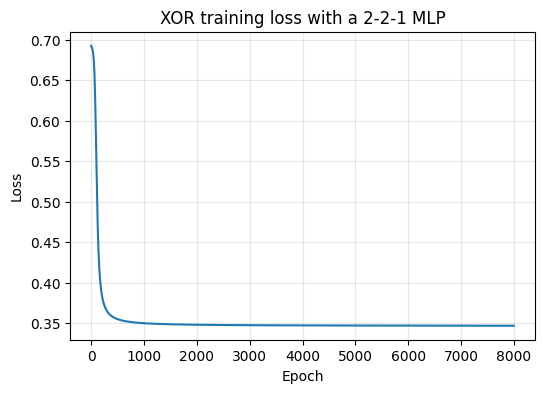

In [8]:
def train_xor(epochs=8000, lr=0.5, seed=1):
    rng = np.random.default_rng(seed)
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
    y = np.array([[0], [1], [1], [0]], dtype=float)
    W1 = rng.standard_normal((2, 2)) * 0.5; b1 = np.zeros((1, 2))
    W2 = rng.standard_normal((2, 1)) * 0.5; b2 = np.zeros((1, 1))
    losses = []
    for ep in range(epochs):
        Z1 = X @ W1 + b1; A1 = np.tanh(Z1)
        Z2 = A1 @ W2 + b2; A2 = sigmoid(Z2)
        loss = bce(y, A2)
        losses.append(loss)
        # Backprop
        dZ2 = (A2 - y)
        dW2 = A1.T @ dZ2 / len(X); db2 = dZ2.mean(axis=0, keepdims=True)
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * (1 - np.tanh(Z1) ** 2)
        dW1 = X.T @ dZ1 / len(X); db1 = dZ1.mean(axis=0, keepdims=True)
        W1 -= lr * dW1; b1 -= lr * db1; W2 -= lr * dW2; b2 -= lr * db2
    preds = (sigmoid(np.tanh(X @ W1 + b1) @ W2 + b2) > 0.5).astype(int)
    return losses, preds, y.astype(int)

losses, preds, y_xor_int = train_xor()
print('Predictions:', preds.ravel(), 'Truth:', y_xor_int.ravel())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('XOR training loss with a 2-2-1 MLP')
ax.grid(alpha=0.3); save_fig('03_xor_loss'); plt.show()


## 7. Optimisers: SGD vs Momentum vs RMSprop vs Adam

We minimise a noisy quadratic to visualise convergence speed.

Saved images/04_optimisers.png


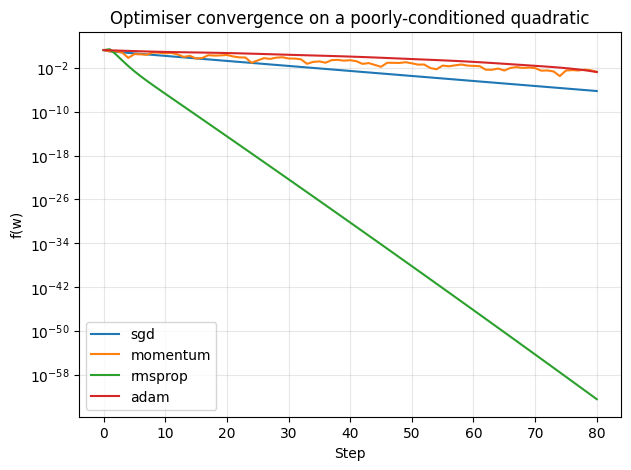

In [9]:
def f(w):   return 0.5 * (w[0] ** 2 + 10 * w[1] ** 2)
def grad(w): return np.array([w[0], 10 * w[1]])

def optimise(name, steps=80, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
    w = np.array([5.0, 1.0])
    m = np.zeros_like(w); v = np.zeros_like(w)
    path = [w.copy()]
    for t in range(1, steps + 1):
        g = grad(w)
        if name == 'sgd':
            w -= lr * g
        elif name == 'momentum':
            m = beta1 * m + g; w -= lr * m
        elif name == 'rmsprop':
            v = beta2 * v + (1 - beta2) * g ** 2; w -= lr * g / (np.sqrt(v) + eps)
        elif name == 'adam':
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g ** 2
            m_hat = m / (1 - beta1 ** t); v_hat = v / (1 - beta2 ** t)
            w -= lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(w.copy())
    return np.array(path)

fig, ax = plt.subplots(figsize=(7, 5))
for name in ['sgd', 'momentum', 'rmsprop', 'adam']:
    path = optimise(name)
    ax.plot([f(w) for w in path], label=name)
ax.set_xlabel('Step'); ax.set_ylabel('f(w)'); ax.set_yscale('log')
ax.set_title('Optimiser convergence on a poorly-conditioned quadratic')
ax.legend(); ax.grid(alpha=0.3)
save_fig('04_optimisers'); plt.show()


## 8. Complete neural network on the moons dataset

Putting everything together to train an end-to-end binary classifier.

Test accuracy: 0.985
Saved images/05_moons_curves.png


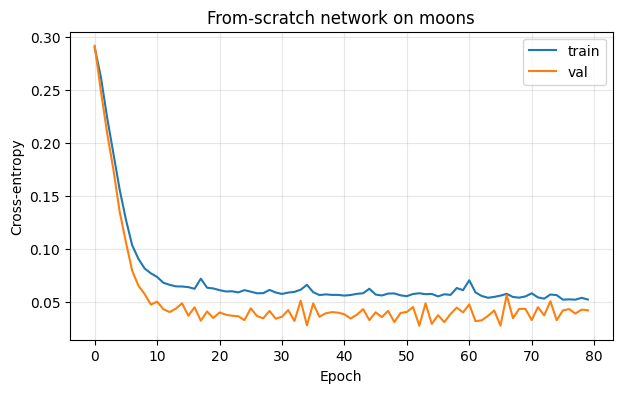

In [10]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
y_train_oh = np.eye(2)[y_train]
y_test_oh = np.eye(2)[y_test]

class NeuralNet:
    def __init__(self, sizes, lr=0.05, seed=0):
        rng = np.random.default_rng(seed)
        self.params = {}
        for l in range(1, len(sizes)):
            self.params[f'W{l}'] = rng.standard_normal((sizes[l-1], sizes[l])) * np.sqrt(2 / sizes[l-1])
            self.params[f'b{l}'] = np.zeros((1, sizes[l]))
        self.sizes = sizes; self.lr = lr
        self.m = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.v = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.t = 0

    def forward(self, X):
        cache = {'A0': X}; A = X
        for l in range(1, len(self.sizes) - 1):
            Z = A @ self.params[f'W{l}'] + self.params[f'b{l}']
            A = np.maximum(0, Z)
            cache[f'Z{l}'] = Z; cache[f'A{l}'] = A
        L = len(self.sizes) - 1
        Z = A @ self.params[f'W{L}'] + self.params[f'b{L}']
        cache[f'Z{L}'] = Z; cache[f'A{L}'] = softmax(Z)
        return cache[f'A{L}'], cache

    def backward(self, cache, y):
        grads = {}; L = len(self.sizes) - 1
        m = y.shape[0]
        dZ = cache[f'A{L}'] - y
        for l in range(L, 0, -1):
            grads[f'W{l}'] = cache[f'A{l-1}'].T @ dZ / m
            grads[f'b{l}'] = dZ.mean(axis=0, keepdims=True)
            if l > 1:
                dA = dZ @ self.params[f'W{l}'].T
                dZ = dA * (cache[f'Z{l-1}'] > 0)
        return grads

    def step_adam(self, grads, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for k in grads:
            self.m[k] = beta1 * self.m[k] + (1 - beta1) * grads[k]
            self.v[k] = beta2 * self.v[k] + (1 - beta2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - beta1 ** self.t)
            v_hat = self.v[k] / (1 - beta2 ** self.t)
            self.params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + eps)

    def fit(self, X, y, epochs=80, batch=64, X_val=None, y_val=None):
        train_loss, val_loss = [], []
        for ep in range(epochs):
            idx = np.random.permutation(len(X))
            for s in range(0, len(X), batch):
                b = idx[s:s + batch]
                out, cache = self.forward(X[b])
                grads = self.backward(cache, y[b])
                self.step_adam(grads)
            out, _ = self.forward(X); train_loss.append(cce(y, out))
            if X_val is not None:
                vout, _ = self.forward(X_val); val_loss.append(cce(y_val, vout))
        return train_loss, val_loss

    def predict(self, X):
        out, _ = self.forward(X)
        return out.argmax(axis=1)

net = NeuralNet([2, 16, 16, 2], lr=0.01)
tr, va = net.fit(X_train_s, y_train_oh, epochs=80, batch=64,
                 X_val=X_test_s, y_val=y_test_oh)
acc = (net.predict(X_test_s) == y_test).mean()
print(f'Test accuracy: {acc:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tr, label='train'); ax.plot(va, label='val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy')
ax.set_title('From-scratch network on moons'); ax.legend(); ax.grid(alpha=0.3)
save_fig('05_moons_curves'); plt.show()


## 9. TensorFlow / Keras equivalent

The same model in Keras takes a few lines. We keep the import optional so the rest of the notebook still runs without TensorFlow installed.

In [11]:
try:
    import tensorflow as tf
    tf.random.set_seed(42)
    keras_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax'),
    ])
    keras_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    hist = keras_model.fit(X_train_s, y_train_oh, validation_data=(X_test_s, y_test_oh),
                           epochs=40, batch_size=64, verbose=0)
    print('Final val accuracy:', hist.history['val_accuracy'][-1])
except ModuleNotFoundError:
    print('TensorFlow not installed - skipping Keras section.')


I0000 00:00:1778973068.600499  546831 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


: 

## 10. Exercise solutions

### 10.1 Multiple-choice answers (with brief justifications)

| Q | Answer | Why |
|---|--------|-----|
| 1 | (b) Synaptic strength | A weight scales the input signal, mirroring synaptic strength. |
| 2 | (c) Cannot solve non-linearly separable problems | A single linear boundary cannot represent XOR. |
| 3 | (d) ReLU | Standard default for deep hidden layers; cheap and avoids saturation for positive inputs. |
| 4 | (b) Dying ReLU | Leaky ReLU keeps a small negative slope so neurons can recover. |
| 5 | (b) Stable gradients and faster convergence | Scaling avoids dominant features and vanishing/exploding gradients. |
| 6 | (c) Categorical cross-entropy | The natural loss for multi-class probability outputs. |
| 7 | (c) Chain rule | Each layer's gradient is the product of its local derivative with the upstream gradient. |
| 8 | (b) Counteract the early-iteration bias of the moving averages | Without correction, m and v are heavily biased toward zero. |
| 9 | (c) Dropout | Random deactivation forces redundancy and reduces over-fitting. |
| 10 | (b) Automatic differentiation (autograd) | Frameworks build a computational graph and differentiate it for you. |


### 10.2 Why a stack of linear layers is still linear
If every layer is $f_l(x) = W_l x + b_l$, then composing two linear layers gives
$f_2(f_1(x)) = W_2 (W_1 x + b_1) + b_2 = (W_2 W_1) x + (W_2 b_1 + b_2)$, which is another affine map with weights $W_2 W_1$ and bias $W_2 b_1 + b_2$. Adding more linear layers only changes those constants. Non-linear activations are what allow the network to represent non-linear functions.

In [ ]:
rng = np.random.default_rng(0)
W1, b1 = rng.standard_normal((4, 8)), rng.standard_normal((1, 8))
W2, b2 = rng.standard_normal((8, 3)), rng.standard_normal((1, 3))
W3, b3 = rng.standard_normal((3, 2)), rng.standard_normal((1, 2))
X = rng.standard_normal((5, 4))
stacked = ((X @ W1 + b1) @ W2 + b2) @ W3 + b3
W_eff = W1 @ W2 @ W3; b_eff = (b1 @ W2 + b2) @ W3 + b3
single = X @ W_eff + b_eff
print('Max absolute difference:', np.max(np.abs(stacked - single)))


### 10.3 Vanishing gradient problem and susceptible activations
Vanishing gradients occur when the product of layer Jacobians shrinks exponentially with depth. Sigmoid saturates outside roughly $[-4, 4]$ with derivative $\le 0.25$, so each layer multiplies the gradient by a factor below one. Tanh has the same problem but with a max derivative of 1.0 — better than sigmoid but still prone to saturation. ReLU's derivative is 0 or 1, so it suffers less, but very negative pre-activations create the 'dying ReLU' problem.

In [ ]:
x = np.linspace(-8, 8, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, sigmoid_deriv(x), label="sigmoid'")
ax.plot(x, tanh_deriv(x), label="tanh'")
ax.plot(x, relu_deriv(x), label="relu'")
ax.set_xlabel('pre-activation'); ax.set_ylabel('derivative')
ax.set_title('Activation derivatives - regions of saturation')
ax.legend(); ax.grid(alpha=0.3); save_fig('06_derivatives'); plt.show()


### 10.4 Two-layer backprop derivation (ReLU hidden, sigmoid output)
Forward pass:
$z_1 = W_1 x + b_1, \; a_1 = \max(0, z_1), \; z_2 = W_2 a_1 + b_2, \; \hat{y} = \sigma(z_2)$.

With binary cross-entropy loss $L = -y \log \hat{y} - (1-y) \log(1-\hat{y})$:

- $\partial L / \partial z_2 = \hat{y} - y$
- $\partial L / \partial W_2 = a_1^T (\hat{y} - y)$
- $\partial L / \partial b_2 = \hat{y} - y$
- $\partial L / \partial a_1 = (\hat{y} - y) W_2^T$
- $\partial L / \partial z_1 = \partial L / \partial a_1 \odot \mathbf{1}[z_1 > 0]$
- $\partial L / \partial W_1 = x^T (\partial L / \partial z_1)$, $\partial L / \partial b_1 = \partial L / \partial z_1$


### 10.5 Batch vs SGD vs mini-batch
**Batch gradient descent** uses the whole training set per update. Updates are low-variance and the path is smooth but slow on large datasets; one epoch = one update.

**SGD** updates on a single example. Very noisy, can escape shallow minima, but convergence is jittery and the final loss often oscillates.

**Mini-batch GD** sits between the two: 32-512 examples per update. It exploits vectorised hardware and gives a useful trade-off between variance and throughput. This is what is used in practice.

### 10.6 How Adam adapts the learning rate per parameter
Adam maintains two exponential moving averages per parameter — $m_t$ for the gradient and $v_t$ for its square. The effective learning rate becomes $\eta \hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)$, so parameters with consistently large gradients get a smaller effective step than those with small or noisy gradients. Compared to a fixed learning rate this rescales each dimension on the fly, which is particularly helpful when parameter magnitudes differ by orders of magnitude (e.g. embedding tables vs final-layer biases).

In [ ]:
# Visualise Adam vs SGD step magnitudes on the noisy quadratic above
sgd_path = optimise('sgd'); adam_path = optimise('adam')
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.linalg.norm(np.diff(sgd_path, axis=0), axis=1), label='SGD step size')
ax.plot(np.linalg.norm(np.diff(adam_path, axis=0), axis=1), label='Adam step size')
ax.set_xlabel('Step'); ax.set_ylabel('|step|'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Per-step update magnitude'); save_fig('07_adam_step'); plt.show()


---
*End of Chapter 1 — all figures are saved into `images/` for the book bundle.*
